LA LIGA 2025-26: ANÁLISIS DE EFICIENCIA - PUNTOS vs VALOR DE PLANTILLA
CON ANÁLISIS DE REGRESIÓN: RENDIMIENTO ESPERADO vs REAL

📊 DATOS CARGADOS:

         TEAM  ARRIVALS_M  DEPARTURES_M  BALANCE_M  GOALS_DIFFERENCE  POINTS  TOTAL_MARKET_VALUE_M
  REAL MADRID      167.50         27.00    -140.50                42      86               1300.00
    BARCELONA       27.50         31.20       3.70                59      94               1190.00
     ATLÉTICO      230.95        145.50     -85.45                18      69                646.90
    VILLAREAL      105.50        108.00       2.50                26      72                375.55
        BETIS       62.50         61.63      -0.87                11      60                253.05
        CELTA       15.00         56.70      41.70                 5      54                207.60
       GETAFE        1.80         12.60      10.80                -6      51                 95.60
         RAYO        7.10         12.30       5.20           

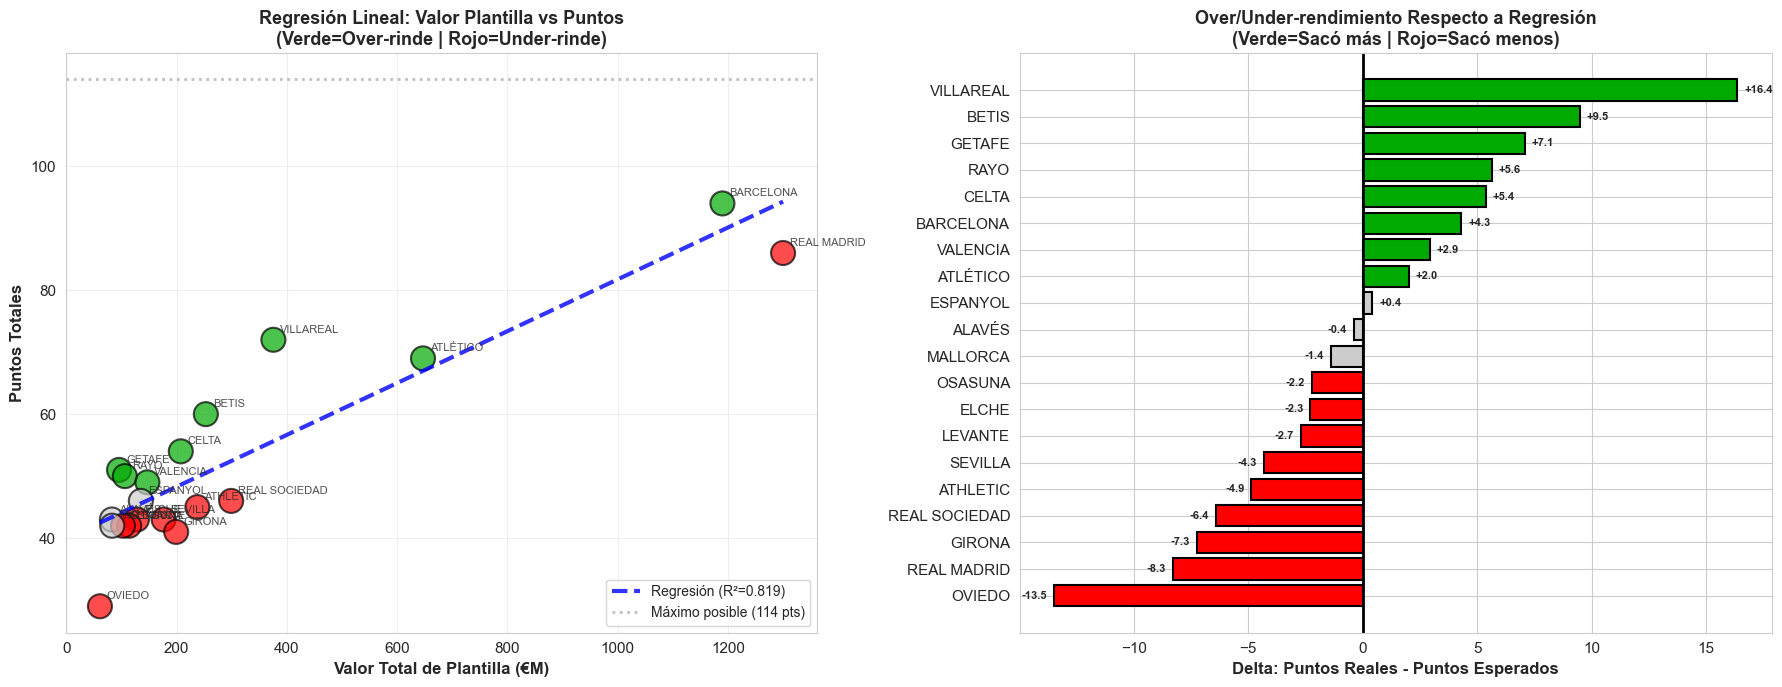


✅ Gráfico 1 guardado: proyecto_1_regresion_analisis.png


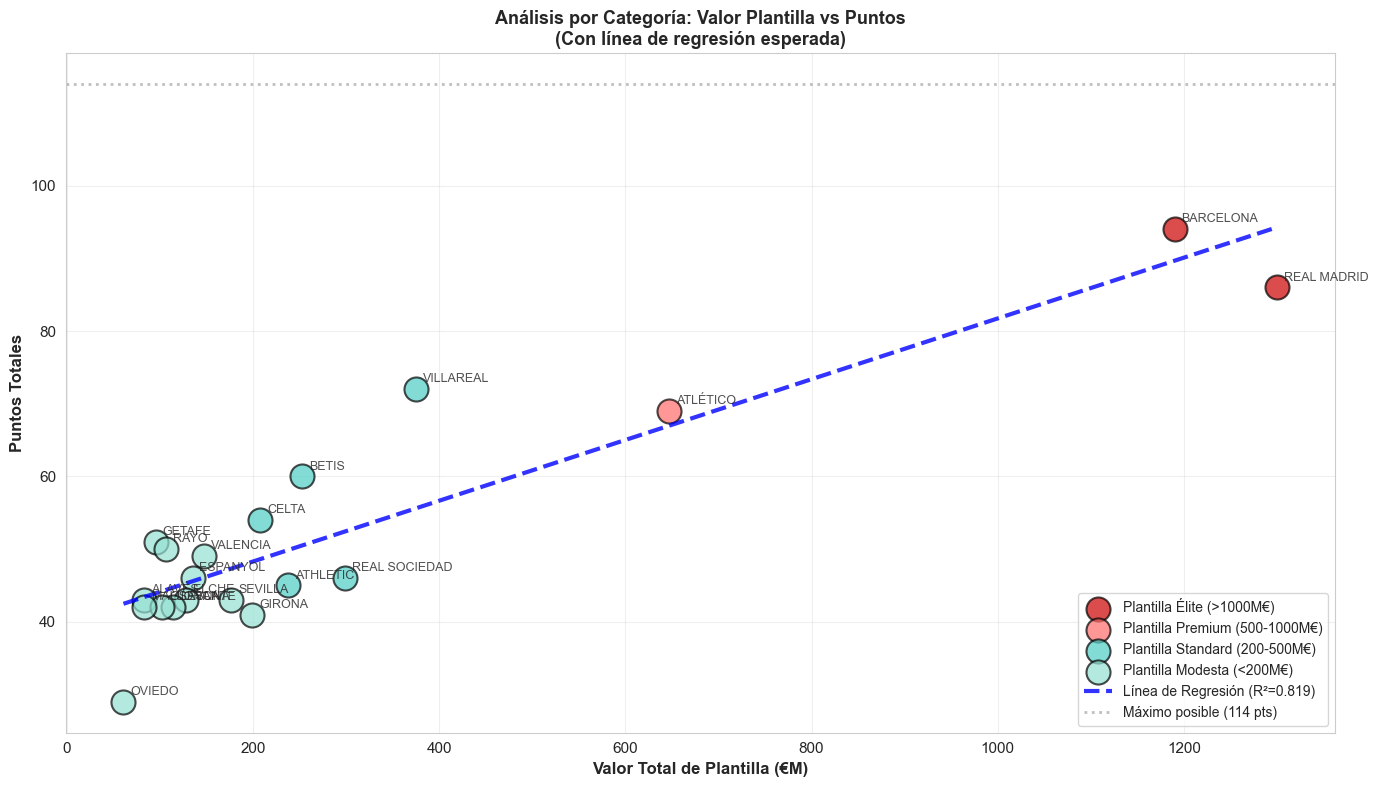

✅ Gráfico 2 guardado: proyecto_1_regresion_categorizado.png

📋 TABLA RESUMEN: RENDIMIENTO vs EXPECTATIVA

         Team  Squad Value (€M)  Actual Points  Expected Points      Delta        Performance
    VILLAREAL            375.55             72        55.632775  16.367225   Over-rendimiento
        BETIS            253.05             60        50.510104   9.489896   Over-rendimiento
       GETAFE             95.60             51        43.925903   7.074097   Over-rendimiento
         RAYO            106.20             50        44.369171   5.630829   Over-rendimiento
        CELTA            207.60             54        48.609488   5.390512   Over-rendimiento
    BARCELONA           1190.00             94        89.691220   4.308780   Over-rendimiento
     VALENCIA            147.03             49        46.076589   2.923411   Over-rendimiento
     ATLÉTICO            646.90             69        66.980014   2.019986   Over-rendimiento
     ESPANYOL            135.15             46  

In [4]:
# ============================================
# PROYECTO 1: ANÁLISIS FINANCIERO LA LIGA 2025-26
# DATOS REALES - TU DATASET
# MÉTRICA: PUNTOS POR MILLÓN DE VALOR DE PLANTILLA
# CON REGRESIÓN LINEAL: RENDIMIENTO ESPERADO vs REAL
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression

# Configurar estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

# ============================================
# CARGAR TUS DATOS REALES
# ============================================

df = pd.read_excel('Dataset.xlsx')

print("=" * 130)
print("LA LIGA 2025-26: ANÁLISIS DE EFICIENCIA - PUNTOS vs VALOR DE PLANTILLA")
print("CON ANÁLISIS DE REGRESIÓN: RENDIMIENTO ESPERADO vs REAL")
print("=" * 130)

print("\n📊 DATOS CARGADOS:\n")
print(df.to_string(index=False))

# ============================================
# CONSTANTS
# ============================================

MAX_POINTS = 38 * 3  # 114 puntos máximos

# ============================================
# CALCULAR MÉTRICAS NORMALIZADAS
# ============================================

# Normalizar puntos al máximo posible
df['Points_Percentage'] = (df['POINTS'] / MAX_POINTS) * 100

# Eficiencia normalizada
df['Efficiency_Normalized'] = df['Points_Percentage'] / df['TOTAL_MARKET_VALUE_M']

# Categorizar por tamaño de plantilla
df['Squad_Size_Category'] = df['TOTAL_MARKET_VALUE_M'].apply(
    lambda x: 'Plantilla Élite (>1000M€)' if x > 1000
              else 'Plantilla Premium (500-1000M€)' if x >= 500
              else 'Plantilla Standard (200-500M€)' if x >= 200
              else 'Plantilla Modesta (<200M€)'
)

# ============================================
# REGRESIÓN LINEAL: VALOR PLANTILLA → PUNTOS
# ============================================

print("\n" + "=" * 130)
print("📊 ANÁLISIS DE REGRESIÓN LINEAL")
print("=" * 130)

# Entrenar modelo: Valor plantilla → Puntos conseguidos
X = df[['TOTAL_MARKET_VALUE_M']].values
y = df['POINTS'].values

modelo = LinearRegression()
modelo.fit(X, y)

# Obtener parámetros
slope = modelo.coef_[0]
intercept = modelo.intercept_
r_squared = modelo.score(X, y)

print(f"\nFórmula de la regresión:")
print(f"  Puntos Esperados = {slope:.4f} × Valor_Plantilla + {intercept:.2f}")
print(f"  R² (ajuste del modelo): {r_squared:.4f} ({r_squared*100:.2f}%)")
print(f"\nInterpretación:")
print(f"  - Por cada €1M adicional en valor de plantilla, se espera {slope:.4f} puntos más")
print(f"  - El modelo explica el {r_squared*100:.2f}% de la variabilidad en puntos")

# Predecir para cada equipo
df['Points_Expected'] = modelo.predict(X)
df['Performance_Delta'] = df['POINTS'] - df['Points_Expected']
df['Performance_Type'] = df['Performance_Delta'].apply(
    lambda x: 'Over-rendimiento' if x > 2 else 'Under-rendimiento' if x < -2 else 'Rendimiento Normal'
)

print("\n" + "=" * 130)
print("📊 COMPARACIÓN: RENDIMIENTO ESPERADO vs REAL")
print("=" * 130)

comparacion = df[['TEAM', 'TOTAL_MARKET_VALUE_M', 'POINTS', 'Points_Expected', 
                  'Performance_Delta', 'Performance_Type', 'Squad_Size_Category']].copy()
comparacion = comparacion.sort_values('Performance_Delta', ascending=False)
comparacion.columns = ['Team', 'Squad Value (€M)', 'Actual Points', 'Expected Points', 
                       'Delta (Actual-Expected)', 'Performance', 'Category']

print("\n" + comparacion.to_string(index=False))

# ============================================
# TOP INSIGHTS
# ============================================

print("\n" + "=" * 130)
print("🎯 INSIGHTS CLAVE")
print("=" * 130)

# Over-rendimiento
over = df[df['Performance_Delta'] > 2].sort_values('Performance_Delta', ascending=False)
print(f"\n💚 EQUIPOS CON OVER-RENDIMIENTO (sacaron más de lo esperado):")
for idx, (i, row) in enumerate(over.iterrows(), 1):
    print(f"   {idx}. {row['TEAM']}")
    print(f"      └─ Plantilla: €{row['TOTAL_MARKET_VALUE_M']:.1f}M")
    print(f"      └─ Esperado: {row['Points_Expected']:.1f} pts | Real: {row['POINTS']:.0f} pts")
    print(f"      └─ Diferencia: +{row['Performance_Delta']:.1f} puntos (¡MÁS de lo esperado!)")

# Under-rendimiento
under = df[df['Performance_Delta'] < -2].sort_values('Performance_Delta', ascending=True)
print(f"\n❌ EQUIPOS CON UNDER-RENDIMIENTO (sacaron menos de lo esperado):")
for idx, (i, row) in enumerate(under.iterrows(), 1):
    print(f"   {idx}. {row['TEAM']}")
    print(f"      └─ Plantilla: €{row['TOTAL_MARKET_VALUE_M']:.1f}M")
    print(f"      └─ Esperado: {row['Points_Expected']:.1f} pts | Real: {row['POINTS']:.0f} pts")
    print(f"      └─ Diferencia: {row['Performance_Delta']:.1f} puntos (MENOS de lo esperado)")

# Barcelona específicamente
barcelona = df[df['TEAM'] == 'BARCELONA'].iloc[0]
print(f"\n⚔️ BARCELONA (CASO DE ESTUDIO):")
print(f"   Valor plantilla: €{barcelona['TOTAL_MARKET_VALUE_M']:.1f}M")
print(f"   Puntos esperados (por regresión): {barcelona['Points_Expected']:.1f}")
print(f"   Puntos reales: {barcelona['POINTS']:.0f}")
print(f"   Diferencia: {barcelona['Performance_Delta']:+.1f} puntos")
print(f"   Interpretación: {barcelona['Performance_Type']}")
if barcelona['Performance_Delta'] < 0:
    print(f"   → Barcelona UNDER-rendiría. Con €{barcelona['TOTAL_MARKET_VALUE_M']:.0f}M debería haber sacado")
    print(f"     aproximadamente {barcelona['Points_Expected']:.0f} puntos, pero solo sacó {barcelona['POINTS']:.0f}")
else:
    print(f"   → Barcelona OVER-rendiría. Sacó MÁS puntos de los esperados")

# Atlético vs Madrid
atletico = df[df['TEAM'] == 'ATLÉTICO'].iloc[0]
madrid = df[df['TEAM'] == 'REAL MADRID'].iloc[0]

print(f"\n⚔️ ATLÉTICO vs REAL MADRID (ANÁLISIS COMPARATIVO):")
print(f"   Real Madrid:")
print(f"      - Plantilla: €{madrid['TOTAL_MARKET_VALUE_M']:.1f}M → Esperado: {madrid['Points_Expected']:.0f} pts, Real: {madrid['POINTS']:.0f} pts")
print(f"      - Performance: {madrid['Performance_Delta']:+.1f} pts ({madrid['Performance_Type']})")
print(f"   Atlético Madrid:")
print(f"      - Plantilla: €{atletico['TOTAL_MARKET_VALUE_M']:.1f}M → Esperado: {atletico['Points_Expected']:.0f} pts, Real: {atletico['POINTS']:.0f} pts")
print(f"      - Performance: {atletico['Performance_Delta']:+.1f} pts ({atletico['Performance_Type']})")

# ============================================
# DEFINIR COLORES
# ============================================

color_map = {
    'Plantilla Élite (>1000M€)': '#CC0000',
    'Plantilla Premium (500-1000M€)': '#FF6B6B',
    'Plantilla Standard (200-500M€)': '#4ECDC4',
    'Plantilla Modesta (<200M€)': '#95E1D3'
}

color_performance = {
    'Over-rendimiento': '#00AA00',
    'Rendimiento Normal': '#CCCCCC',
    'Under-rendimiento': '#FF0000'
}

# ============================================
# VISUALIZACIÓN 1: Regresión Lineal + Puntos Reales
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Gráfico 1: Regresión con todos los puntos
x_range = np.array([[df['TOTAL_MARKET_VALUE_M'].min()], [df['TOTAL_MARKET_VALUE_M'].max()]])
y_pred = modelo.predict(x_range)

# Colores por performance
colores = [color_performance[perf] for perf in df['Performance_Type']]

axes[0].scatter(df['TOTAL_MARKET_VALUE_M'], df['POINTS'], 
                s=300, alpha=0.7, c=colores, edgecolors='black', linewidth=1.5)

# Línea de regresión
axes[0].plot(x_range, y_pred, 'b--', linewidth=3, label=f'Regresión (R²={r_squared:.3f})', alpha=0.8)

# Línea máxima teórica
axes[0].axhline(y=MAX_POINTS, color='gray', linestyle=':', linewidth=2, label=f'Máximo posible ({MAX_POINTS} pts)', alpha=0.5)

axes[0].set_xlabel('Valor Total de Plantilla (€M)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Puntos Totales', fontsize=12, fontweight='bold')
axes[0].set_title('Regresión Lineal: Valor Plantilla vs Puntos\n(Verde=Over-rinde | Rojo=Under-rinde)', 
                  fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=10, loc='lower right')

# Etiquetas
for idx, row in df.iterrows():
    axes[0].annotate(row['TEAM'], 
                     (row['TOTAL_MARKET_VALUE_M'], row['POINTS']),
                     fontsize=8, alpha=0.8, xytext=(5, 5), textcoords='offset points')

# Gráfico 2: Delta (Diferencia esperado vs real)
ranking_delta = df.sort_values('Performance_Delta', ascending=True)
colores_delta = [color_performance[perf] for perf in ranking_delta['Performance_Type']]

axes[1].barh(ranking_delta['TEAM'], ranking_delta['Performance_Delta'], 
             color=colores_delta, edgecolor='black', linewidth=1.5)
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=2)
axes[1].set_xlabel('Delta: Puntos Reales - Puntos Esperados', fontsize=12, fontweight='bold')
axes[1].set_title('Over/Under-rendimiento Respecto a Regresión\n(Verde=Sacó más | Rojo=Sacó menos)', 
                  fontsize=13, fontweight='bold')

# Valores en barras
for i, (idx, row) in enumerate(ranking_delta.iterrows()):
    valor = row['Performance_Delta']
    axes[1].text(valor + (0.3 if valor > 0 else -0.3), i, f'{valor:+.1f}', 
                va='center', ha='left' if valor > 0 else 'right', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('proyecto_1_regresion_analisis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Gráfico 1 guardado: proyecto_1_regresion_analisis.png")

# ============================================
# VISUALIZACIÓN 2: Valor vs Puntos (separado por categoría + regresión)
# ============================================

fig, ax = plt.subplots(figsize=(14, 8))

# Scatter con categorías
for category in df['Squad_Size_Category'].unique():
    subset = df[df['Squad_Size_Category'] == category]
    ax.scatter(subset['TOTAL_MARKET_VALUE_M'], subset['POINTS'],
               s=300, alpha=0.7, c=color_map[category], 
               edgecolors='black', linewidth=1.5, label=category)

# Línea de regresión
ax.plot(x_range, y_pred, 'b--', linewidth=3, label=f'Línea de Regresión (R²={r_squared:.3f})', alpha=0.8)
ax.axhline(y=MAX_POINTS, color='gray', linestyle=':', linewidth=2, label=f'Máximo posible ({MAX_POINTS} pts)', alpha=0.5)

ax.set_xlabel('Valor Total de Plantilla (€M)', fontsize=12, fontweight='bold')
ax.set_ylabel('Puntos Totales', fontsize=12, fontweight='bold')
ax.set_title('Análisis por Categoría: Valor Plantilla vs Puntos\n(Con línea de regresión esperada)', 
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=10)

# Etiquetas
for idx, row in df.iterrows():
    ax.annotate(row['TEAM'], 
                (row['TOTAL_MARKET_VALUE_M'], row['POINTS']),
                fontsize=9, alpha=0.8, xytext=(5, 5), textcoords='offset points')

plt.tight_layout()
plt.savefig('proyecto_1_regresion_categorizado.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Gráfico 2 guardado: proyecto_1_regresion_categorizado.png")

# ============================================
# TABLA RESUMEN PARA LINKEDIN
# ============================================

print("\n" + "=" * 130)
print("📋 TABLA RESUMEN: RENDIMIENTO vs EXPECTATIVA")
print("=" * 130)

resumen = df[['TEAM', 'TOTAL_MARKET_VALUE_M', 'POINTS', 'Points_Expected', 
              'Performance_Delta', 'Performance_Type']].copy()
resumen = resumen.sort_values('Performance_Delta', ascending=False)
resumen.columns = ['Team', 'Squad Value (€M)', 'Actual Points', 'Expected Points', 
                   'Delta', 'Performance']

print("\n" + resumen.to_string(index=False))

print("\n" + "=" * 130)
print("✅ PROYECTO 1 COMPLETADO")
print("=" * 130)
print("\nArchivos generados para LinkedIn:")
print("  1. proyecto_1_regresion_analisis.png")
print("  2. proyecto_1_regresion_categorizado.png")
print("\nMÉTRICA CLAVE:")
print("  Regresión Lineal: Valor de Plantilla → Puntos Esperados")
print("  Delta: Puntos Reales - Puntos Esperados")
print("  Interpretación: Qué equipos rindieron mejor/peor que lo esperado")